# Phân tích dữ liệu Bayesian - IUH.

### Lab 3. Ngày 24/01/2024.

> Mục tiêu: 
- Ôn tập về việc phân tích Bayes.
- Ôn tập việc tính xác suất của biến ngẫu nhiên liên tục.

**Bài 1.**

Trong một hộp, có $10$ viên bi gồm hai màu: xanh và đỏ nhưng chưa biết cụ thể số lượng. Ta gọi $A_k$ là biến cố chỉ số lượng bi đỏ trong hộp với $0 \le k \le 10.$ Người ta lần lượt lấy ra từ hộp, mỗi lần một viên bi cho đến khi hết hộp. 

1) Hãy cho biết xác suất hậu nghiệm của các biến cố, sau khi lần đầu tiên bốc được bi đỏ.

2) Hãy viết chương trình thực hiện phân tích Bayes cho xác suất của các biến cố ở trên khi dãy bi thu được ở $10$ lần là:
$$R,R,B,R,B,B,B,R,R,R.$$

In [ ]:
#CODE HERE

**Bài 2.** Hãy tìm hiểu phân phối mũ (exponential distribution) thông qua các đoạn code tham khảo sau đây:

In [6]:
from numpy import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
x = random.exponential(scale=2, size=(2, 3))
print(x)

[[1.96900317 5.12055181 1.94844231]
 [5.81398442 1.13967859 0.47443007]]


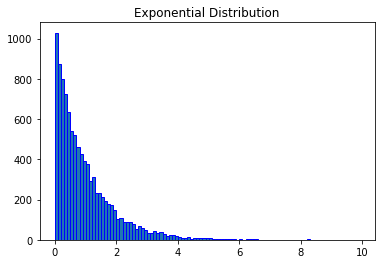

In [8]:
#fixing the seed for reproducibility of the result
np.random.seed(10)
size = 10000
#drawing 10000 sample from exponential distribution
sample = np.random.exponential(1, size)
bin = np.arange(0,10,0.1)

plt.hist(sample, bins=bin, edgecolor='blue') 
plt.title("Exponential Distribution") 
plt.show()

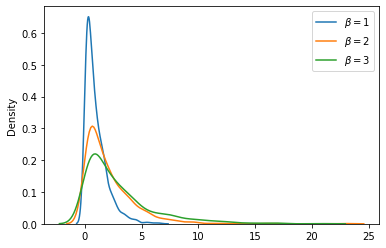

In [9]:
np.random.seed(10)
size = 1000
#plotting 1000 sample from different exponential distribution
sns.kdeplot(np.random.exponential(1, size))
sns.kdeplot(np.random.exponential(2, size))
sns.kdeplot(np.random.exponential(3, size))

plt.legend([r"$\beta = 1$", 
            r"$\beta = 2$", 
            r"$\beta = 3$"])
plt.show()

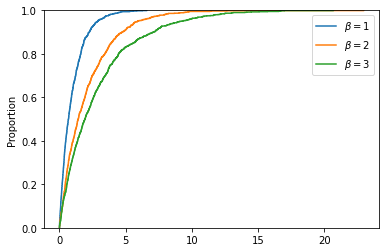

In [10]:
np.random.seed(10)
size = 1000
#plotting 1000 sample from different exponential distribution
sns.ecdfplot(np.random.exponential(1, size))
sns.ecdfplot(np.random.exponential(2, size))
sns.ecdfplot(np.random.exponential(3, size))

plt.legend([r"$\beta = 1$", 
            r"$\beta = 2$", 
            r"$\beta = 3$"])
plt.show()

**Câu hỏi:** Giả sử tuổi thọ (tính theo năm) của một mạch điện tử trong máy tính là đại lượng ngẫu nhiên có phân phối mũ với kỳ vọng là 6.25. Thời gian bảo hành của mạch điện tử là 5 năm. Tính xác suất để mạch điện tử phải thay thế trong thời gian bảo hành.

**Bài 3.** (*nhắc lại về phân phối chuẩn*)

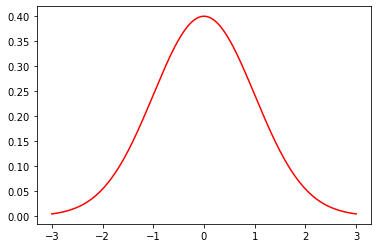

In [13]:
from scipy.stats import norm

#x-axis ranges from -3 and 3 with .001 steps
x = np.arange(-3, 3, 0.001)

#plot normal distribution with mean 0 and standard deviation 1
plt.plot(x, norm.pdf(x, 0, 1), color='red',)

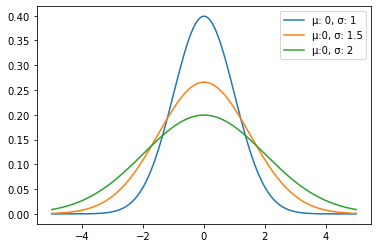

In [14]:
x = np.arange(-5, 5, 0.001)

#define multiple normal distributions
plt.plot(x, norm.pdf(x, 0, 1), label='μ: 0, σ: 1')
plt.plot(x, norm.pdf(x, 0, 1.5), label='μ:0, σ: 1.5')
plt.plot(x, norm.pdf(x, 0, 2), label='μ:0, σ: 2')

#add legend to plot
plt.legend()

**Câu hỏi:** Cho biến ngẫu nhiên $X$ có phân phối chuẩn với $\mu = 4, \sigma = -1.$ Tính xác suất có điều kiện $$P(X \le 0 | X > -3).$$

**Bài 4.** Chiều cao (tính bằng cm) của sinh viên trong lớp KHDL16A là đại lượng ngẫu nhiên liên tục có phân bố chuẩn với kỳ vọng $160cm$ và độ lệch chuẩn $15cm$. <br>
**a)** Hãy sinh ra một mảng dữ liệu của $X$ với kích thước $55$ và trực quan dữ liệu đó bằng thư viện thích hợp. <br>
**b)** Tính xác suất để sinh viên được chọn trong lớp thì cao hơn $170 (cm)$? Xác suất để chiều cao từ $165cm$ đến $172cm$? <br>
**c)** Tìm $x$ sao cho xác suất để chiều cao của sinh viên không vượt quá $x$ thì bằng $0.2024.$ <br>

In [15]:
data = np.random.normal(size=55,loc=160,scale=15)
data

array([142.12152498, 187.33175651, 171.9336463 , 190.0563986 ,
       147.04262352, 182.6830496 , 142.77025654, 155.66169582,
       158.03404929, 142.62021266, 184.32982268, 180.28084089,
       151.8597588 , 155.22516485, 161.13794583, 176.301181  ,
       146.81452227, 164.55476573, 151.5078589 , 164.28005322,
       143.32783407, 155.39357184, 160.91929987, 153.1282644 ,
       149.27403019, 161.63657748, 145.43630382, 180.87176906,
       151.57917399, 141.9402761 , 164.58968175, 169.38964882,
       141.07429001, 174.22741575, 149.20759669, 125.06592317,
       155.92653595, 178.6758812 , 152.91547449, 169.88622335,
       151.84168209, 151.41364407, 178.19158346, 138.43078284,
       155.38321524, 146.60438758, 175.58060347, 124.18958776,
       189.14354149, 165.72577512, 155.89795845, 153.73347499,
       165.90176738, 157.13597609, 148.72877231])

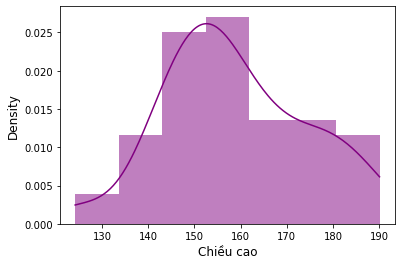

In [16]:
p=sns.histplot(data, color="purple", kde=True, stat="density", linewidth=0)
p.set_xlabel("Chiều cao", fontsize = 12)
p.set_ylabel("Density", fontsize = 12);

In [20]:
import scipy.stats as stats
X= stats.norm(loc=160,scale=15)
print(X.sf(170),1-X.cdf(170))

0.2524925375469229 0.2524925375469229


In [21]:
print('Xác suất để sinh viên được chọn trong lớp cao hơn 170cm là:',X.sf(170).round(4))

Xác suất để sinh viên được chọn trong lớp  cao hơn 170cm là: 0.2525


In [25]:
prob = X.cdf(172)-X.cdf(165)
print('Xác suất để chọn được sinh viên trong lớp chiều cao từ 165cm đến 172cm là:', prob.round(4))

Xác suất để chọn được sinh viên trong lớp chiều cao từ 165cm đến 172cm là: 0.1576


**Bài 5.1.** Cho biến ngẫu nhiên liên tục $X$ có hàm mật độ xác suất sau đây
$$f_X(x)=\left\{ \begin{align}
  & k(x^2-5x+4) ,\text{   } 1 \le x \le 4 \\ 
 & 0,\text{    } \text{khác}. \\ 
\end{align} \right..$$

1) Tìm $k$.

Để tìm k ta tính $\int_{-\infty}^{\infty} f_X(x)dx=1$:
$$1=\int_{1}^{4} k(x^2-5x+4)dx$$

In [ ]:
from sympy.abc import x,y,z,k
f=k*(x**2-5*x+4)
tp=integrate(f,(x,1,4))
tp

In [ ]:
solve([(-9*k)/2-1],k)

In [ ]:
f=(x**2-5*x+4)*-2/9
f

2) Tính kỳ vọng và phương sai của phân phối này.

Ta có  $E[X]= \int_{-\infty}^{\infty} xf_X(x)dx$

In [ ]:
E_X=integrate(x*f,(x,1,4))
E_X

Ta có $Var[X]= E[X^2] - E[X]^2$

In [ ]:
E_X2 = integrate(x*x*f,(x,1,4))
E_X2 - (E_X)**2

**Bài 5.2.** Cho biến ngẫu nhiên $X$ có hàm mật độ xác suất là $$f(x) = kx(2-x) \text{ với } 0 \le x \le 2.$$ 

1. Thực hiện lại các thao tác tính toán ở trên.
2. Thử tính mode và median của phân phối này.

In [ ]:
#CODE HERE